# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

# **Pares Tweets-Reply**

In [3]:
# baixando dataset para o collab
import gdown

file_class_caio = "1gRgynvkPYlTI-8yu1kFzIm-xMK7fTZmX"
file_class_victor = "1qZHAFQzkAZDmO-F9VSvY0PqGsHmxDk2u"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "Mandetta_reply_caio.csv", quiet=False)
gdown.download(url_2, "Mandetta_reply_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1gRgynvkPYlTI-8yu1kFzIm-xMK7fTZmX
To: /content/Mandetta_reply_caio.csv
100%|██████████| 2.15M/2.15M [00:00<00:00, 49.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1qZHAFQzkAZDmO-F9VSvY0PqGsHmxDk2u
To: /content/Mandetta_reply_victor.csv
100%|██████████| 2.15M/2.15M [00:00<00:00, 141MB/s]


'Mandetta_reply_victor.csv'

In [4]:
#carregando o dataset
df_caio = pd.read_csv ("Mandetta_reply_caio.csv")
df_victor = pd.read_csv ("Mandetta_reply_victor.csv")

In [5]:
#numero total de instancias no dataset
df_caio.shape

(6479, 4)

In [6]:
#numero total de instancias no dataset
df_victor.shape

(6479, 4)

In [7]:
df_caio.head(20)

,tweet_1,tweet_2,Class,Conflict
0,"“O dia que ele [Mandetta] sair, eu saio junto ...","Demorou, não deveria ne ter sido nomeado mande...",1,0.0
1,A maioria esmagadora dos brasileiros é contrár...,"Como uma cobra ratoeira, está o senhor senador...",1,1.0
2,A maioria esmagadora dos brasileiros é contrár...,#ForaMandettaTraira Eu não fui entrevistada!...,1,0.0
3,Mandetta e sua política de isolamento estão lo...,Mandetta é um TRAIDOR!!!! #ForaMandettaUrgente,1,0.0
4,Demissão de Mandetta é rejeitada por 76% dos b...,"Mandetta, ficou deslumbrado ao microfone e o t...",1,0.0
5,"O ministro da Saúde, Henrique Mandetta, disse ...",Que o Mandetta va tarde,1,0.0
6,Quem era Mandetta antes de virar Ministro da S...,Não sei porque estão criticando o por demitir...,1,0.0
7,A maioria esmagadora dos brasileiros é contrár...,Bora lá provar para o senhor senador Alvaro Di...,1,0.0
8,"Parece que é verdade, veja a reportagem de 201...","Eu escutei o dia q Mandetta ""desceu a lenha na...",1,0.0
9,Planalto investiga assessores de Mandetta e pr...,"Do nada o Mandetta morrendo de ""ataque cardi...",1,0.0


In [8]:
df_victor.head(20)

,tweet_1,tweet_2,Class,Conflict
0,"“O dia que ele [Mandetta] sair, eu saio junto ...","Demorou, não deveria ne ter sido nomeado mande...",1,0.0
1,A maioria esmagadora dos brasileiros é contrár...,"Como uma cobra ratoeira, está o senhor senador...",1,1.0
2,A maioria esmagadora dos brasileiros é contrár...,#ForaMandettaTraira Eu não fui entrevistada!...,1,0.0
3,Mandetta e sua política de isolamento estão lo...,Mandetta é um TRAIDOR!!!! #ForaMandettaUrgente,1,0.0
4,Demissão de Mandetta é rejeitada por 76% dos b...,"Mandetta, ficou deslumbrado ao microfone e o t...",1,0.0
5,"O ministro da Saúde, Henrique Mandetta, disse ...",Que o Mandetta va tarde,1,0.0
6,Quem era Mandetta antes de virar Ministro da S...,Não sei porque estão criticando o por demitir...,1,0.0
7,A maioria esmagadora dos brasileiros é contrár...,Bora lá provar para o senhor senador Alvaro Di...,1,0.0
8,"Parece que é verdade, veja a reportagem de 201...","Eu escutei o dia q Mandetta ""desceu a lenha na...",1,0.0
9,Planalto investiga assessores de Mandetta e pr...,"Do nada o Mandetta morrendo de ""ataque cardi...",1,0.0


In [9]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem


In [10]:
for i in range(100):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [11]:
confusion

array([[73.,  3.,  1.],
       [ 2., 21.,  0.],
       [ 0.,  0.,  0.]])

In [12]:
idx_diff

[32, 58, 70, 77, 81, 93]

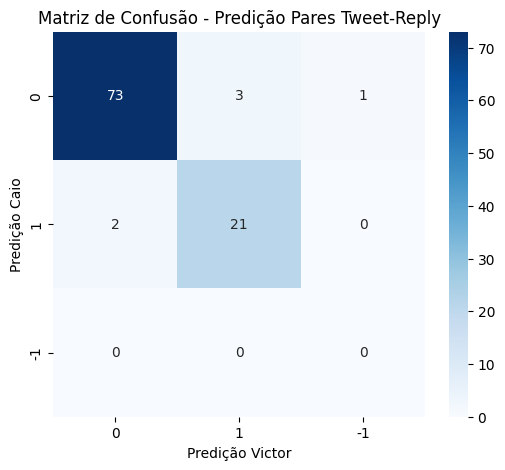

In [13]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet-Reply")
plt.show()

In [14]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff)):
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tweet 1:  Demissão de Mandetta é rejeitada por 76,2%, diz pesquisa da Atlas Político | Política | Valor Econômico
Tweet 2:  QUAL SERÁ O PORQUE DESSA DEMISSÃO??
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  “Eu escolhi minha equipe por currículo..... ” “Nós temos a defesa da vida, a defesa do SUS e a defesa da ciência” Luiz Henrique Mandetta , Ministro da Saúde do Brasil.
Tweet 2:  Basta proclamar frases belas e humanista, que você se tornará  límpido e altruísta. Você ascenderá para um estágio de " cidadão do bem, que tem como efeito o esquecimento de seu passado ( Satanás et al, 2700 A.C) Mandetta é um demagogo seboso.
Classificação Caio:  Conflito
Classificação Victor:  Não Conflito

Tweet 1:  Bruno Boghossian | Mandetta mostra que Bolsonaro é o inimigo do combate ao coronavírus. Dentro do Planalto, ministro demissionário submete presidente a uma humilhação pública ()
Tweet 2:  No mundo imaginário.  No mundo real, o Mandetta teve 4 meses para preparar o

# **Pares Tweets-Quotes**

In [15]:
file_class_caio_quotes = "1jtEK-_LYC3Pw4mfPoKaR7ctYE2lRdIve"
file_class_victor_quotes = "1nO983rW1e9LKef2u6mC_m6EaR9HxYLoq"
url_1 = f"https://drive.google.com/uc?id={file_class_caio_quotes}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor_quotes}"

gdown.download(url_1, "Mandetta_quotes_caio.csv", quiet=False)
gdown.download(url_2, "Mandetta_quotes_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1jtEK-_LYC3Pw4mfPoKaR7ctYE2lRdIve
To: /content/Mandetta_quotes_caio.csv
100%|██████████| 4.97M/4.97M [00:00<00:00, 32.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1nO983rW1e9LKef2u6mC_m6EaR9HxYLoq
To: /content/Mandetta_quotes_victor.csv
100%|██████████| 4.97M/4.97M [00:00<00:00, 29.9MB/s]


'Mandetta_quotes_victor.csv'

In [16]:
df_caio_quotes = pd.read_csv ("Mandetta_quotes_caio.csv")
df_victor_quotes = pd.read_csv ("Mandetta_quotes_victor.csv")

In [17]:
confusion_quotes = np.zeros((3,3))


In [18]:
idx_diff_quotes = []

In [19]:
for i in range(100):
  caio = int(df_caio_quotes.iloc[i]["Conflict"])
  victor = int(df_victor_quotes.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion_quotes[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff_quotes.append(i)


In [20]:
confusion_quotes

array([[80.,  0.,  0.],
       [ 5., 13.,  2.],
       [ 0.,  0.,  0.]])

In [21]:
idx_diff_quotes

[4, 8, 17, 77, 83, 97, 98]

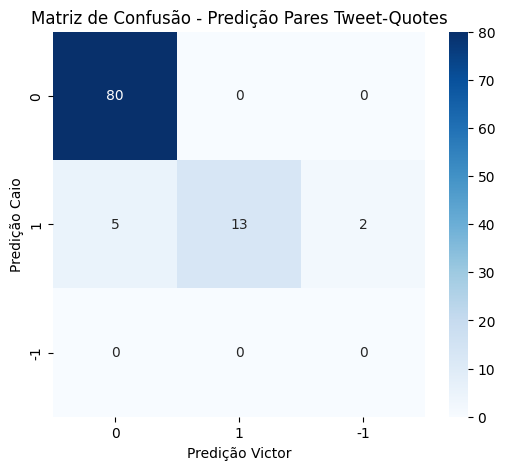

In [22]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion_quotes, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet-Quotes")
plt.show()

In [23]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff_quotes)):
  print("Tweet 1: ", df_caio_quotes.loc[idx_diff_quotes[i], "tweet_1"])
  print("Tweet 2: ", df_caio_quotes.loc[idx_diff_quotes[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio_quotes.loc[idx_diff_quotes[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor_quotes.loc[idx_diff_quotes[i], "Conflict"])])
  print()

Tweet 1:  Demissão de Mandetta é rejeitada por 76% dos brasileiros
Tweet 2:  Ele vai trabalhar em novela da Globo.
Classificação Caio:  Conflito
Classificação Victor:  Não Conflito

Tweet 1:  MANDETTA  - contratou empresa que doou para a sua campanha - comprou itens superfaturados - não tem estratégia a não ser prolongar o isolamento  E agora mais essa!  Ah, mas querem que você acredite que ele vai cair porque BOLSONARO está com "ciúmes".  Pode acreditar amiguinho
Tweet 2:  Plasma é IMPORTANTE na testagem PRA CURAR ou CRIAR VACINA ou estou enganada?  NÃO SABIA dos problemas que desde 2017 JÁ ROLAVA no  ?
Classificação Caio:  Conflito
Classificação Victor:  Não Conflito

Tweet 1:  A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados discordam do afastamento do ministro da Saúde, segundo pesquisa realizada pelo Atlas Político. Vc concorda com o resultado da pesquisa?   via
Tweet 2:  Não! eu acho que já era para ter sido demitido a muito tempo..

# **Pares Tweets Originals**

In [24]:
file_class_caio_originals = "1qkRJlkp6Zsa0SZa9RU4idkKYVEZLQ28p"
file_class_victor_originals = "1rmtVv6DZrdY0IRX1PtKdIbjE7B2nmVrE"
url_1 = f"https://drive.google.com/uc?id={file_class_caio_originals}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor_originals}"

gdown.download(url_1, "Mandetta_originals_caio.csv", quiet=False)
gdown.download(url_2, "Mandetta_originals_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1qkRJlkp6Zsa0SZa9RU4idkKYVEZLQ28p
To: /content/Mandetta_originals_caio.csv
100%|██████████| 2.84M/2.84M [00:00<00:00, 189MB/s]
Downloading...
From: https://drive.google.com/uc?id=1rmtVv6DZrdY0IRX1PtKdIbjE7B2nmVrE
To: /content/Mandetta_originals_victor.csv
100%|██████████| 2.84M/2.84M [00:00<00:00, 152MB/s]


'Mandetta_originals_victor.csv'

In [25]:
df_caio_originals = pd.read_csv ("Mandetta_originals_caio.csv")
df_victor_originals = pd.read_csv ("Mandetta_originals_victor.csv")

In [26]:
confusion_originals = np.zeros((3,3))


In [27]:
idx_diff_originals = []

In [28]:
for i in range(100):
  caio = int(df_caio_originals.iloc[i]["Conflict"])
  victor = int(df_victor_originals.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion_originals[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff_originals.append(i)

In [29]:
confusion_originals

array([[78.,  5.,  2.],
       [ 5.,  9.,  1.],
       [ 0.,  0.,  0.]])

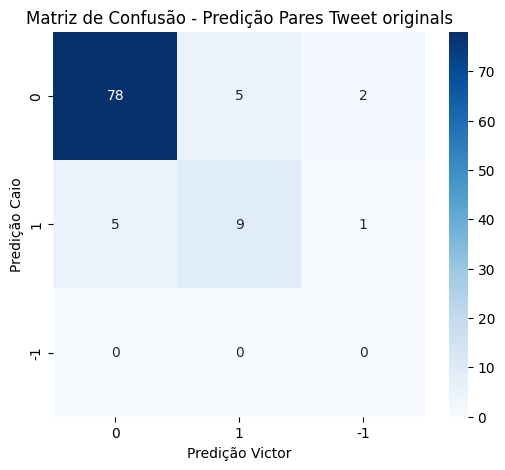

In [30]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion_originals, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet originals")
plt.show()

In [31]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff_originals)):
  print("Tweet 1: ", df_caio_originals.loc[idx_diff_originals[i], "tweet_1"])
  print("Tweet 2: ", df_caio_originals.loc[idx_diff_originals[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio_originals.loc[idx_diff_originals[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor_originals.loc[idx_diff_originals[i], "Conflict"])])
  print()

Tweet 1:  E eu que li a notícia com “Mandetta demite Bolsonaro “ Seria meu sonho
Tweet 2:  mandetta é um oasis de lucidez no meio de um mainstream politico totalmente polarizado
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  So queria mostrar a minha proposta de emenda a constituição: proibido o acesso qualquer pessoa que não defenda o SUS de a qualquer atendimento médico.  O que acham?  ps.: vai se fuder mandetta e bolsonaro
Tweet 2:  Nelson Erich é o novo Ministro sa Saúde! #BolsonatoTemRazao By Mandetta!
Classificação Caio:  Conflito
Classificação Victor:  Não Conflito

Tweet 1:  Bolsonaro demite Mandetta e coloca o Brasil no piloto automático.  Rumo a um prédio
Tweet 2:  "Você conversa hoje, a pessoa entende, diz que concorda, depois muda de ideia e fala tudo diferente. Você vai, conversa, parece que está tudo acertado e, em seguida, o camarada muda o discurso de novo. Já chega, né? Já ajudamos bastante."
Classificação Caio:  Conflito
Classificação Vic

In [32]:
#Organizando classificações de conflitos em quotes de Caio e Victor em um unico DF
df_replys = df_caio.drop('Conflict', axis = 1)
df_replys = df_replys.loc[:49,:]
df_replys['Conflict_Caio'] = df_caio['Conflict']
df_replys['Conflict_Victor'] = df_victor['Conflict']

In [33]:
df_replys

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,"“O dia que ele [Mandetta] sair, eu saio junto ...","Demorou, não deveria ne ter sido nomeado mande...",1,0.0,0.0
1,A maioria esmagadora dos brasileiros é contrár...,"Como uma cobra ratoeira, está o senhor senador...",1,1.0,1.0
2,A maioria esmagadora dos brasileiros é contrár...,#ForaMandettaTraira Eu não fui entrevistada!...,1,0.0,0.0
3,Mandetta e sua política de isolamento estão lo...,Mandetta é um TRAIDOR!!!! #ForaMandettaUrgente,1,0.0,0.0
4,Demissão de Mandetta é rejeitada por 76% dos b...,"Mandetta, ficou deslumbrado ao microfone e o t...",1,0.0,0.0
5,"O ministro da Saúde, Henrique Mandetta, disse ...",Que o Mandetta va tarde,1,0.0,0.0
6,Quem era Mandetta antes de virar Ministro da S...,Não sei porque estão criticando o por demitir...,1,0.0,0.0
7,A maioria esmagadora dos brasileiros é contrár...,Bora lá provar para o senhor senador Alvaro Di...,1,0.0,0.0
8,"Parece que é verdade, veja a reportagem de 201...","Eu escutei o dia q Mandetta ""desceu a lenha na...",1,0.0,0.0
9,Planalto investiga assessores de Mandetta e pr...,"Do nada o Mandetta morrendo de ""ataque cardi...",1,0.0,0.0


In [34]:
#Organizando classificações de conflitos em quotes de Caio e Victor em um unico DF
df_quotes = df_caio_quotes.drop('Conflict',axis=1)
df_quotes = df_quotes.loc[:49,:]
df_quotes['Conflict_Caio'] = df_caio_quotes['Conflict']
df_quotes['Conflict_Victor'] = df_victor_quotes['Conflict']

In [35]:
df_quotes

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,"Segundo o leitor(sic), Mandetta informou aos a...",Muita Tristeza !!! Muita !!!,2,0.0,0.0
1,"A Pepa quer a permanência de Mandetta. Pepa, M...",Nata azeda. #ForaMandettaUrgente,2,0.0,0.0
2,"O ministro da Saúde, Luiz Henrique Mandetta di...","""O ministro da Saúde, Luiz Henrique Mandetta d...",2,0.0,0.0
3,Sílvio Santos também indica nome a Bolsonaro p...,Roque ou Liminha,2,0.0,0.0
4,Demissão de Mandetta é rejeitada por 76% dos b...,Ele vai trabalhar em novela da Globo.,2,1.0,0.0
5,Lula: Mandetta era um privatista do sistema de...,Lulão precisa aparecer mais pra esclarecer ess...,2,0.0,0.0
6,Mandetta e sua política de isolamento estão lo...,Toda unanimidade é burra,2,0.0,0.0
7,E agora ?,#STFVergonhaNacional #AbortoNao MANDETTA CAN...,2,0.0,0.0
8,MANDETTA - contratou empresa que doou para a ...,Plasma é IMPORTANTE na testagem PRA CURAR ou C...,2,1.0,0.0
9,Mandetta gastando 25 milhões com gel pra nego ...,"1- São 25 milhões de UNIDADES de gel, no valor...",2,1.0,1.0


In [36]:
#Organizando classificações de conflitos em originals de Caio e Victor em um unico DF
df_originals = df_caio_originals.drop('Conflict',axis=1)
df_originals = df_originals.loc[:49,:]
df_originals['Conflict_Caio'] = df_caio_originals['Conflict']
df_originals['Conflict_Victor'] = df_victor_originals['Conflict']

In [37]:
df_originals

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,"Demorou, vá com Deus URGENTE: Bolsonaro exon...",parece que as viúvas do mandetta esqueceram qu...,0,0.0,0.0
1,E eu que li a notícia com “Mandetta demite Bol...,mandetta é um oasis de lucidez no meio de um m...,0,0.0,1.0
2,O Mandetta vai tomar naaaaa...... Jacaaaaaaaa !,"Bolsonaro demitindo Mandetta, Babu perdendo o ...",0,1.0,1.0
3,Quem em sã consciência demite um ministro da s...,Minha mae vai rasga a boca falando mal do bono...,0,0.0,0.0
4,So queria mostrar a minha proposta de emenda a...,Nelson Erich é o novo Ministro sa Saúde! #Bols...,0,1.0,0.0
5,Bolsonaro demite Mandetta e coloca o Brasil no...,"""Você conversa hoje, a pessoa entende, diz que...",0,1.0,0.0
6,GloboNews sai da coletiva do Mandetta e corta ...,BDM Online [16.04.20 15:40] ++Mandetta foi cha...,0,0.0,0.0
7,Daqui há alguns dias muitos se perguntarão. M...,Bolsonaro colocou um cara que é igual ao Mande...,0,0.0,0.0
8,"Em despedida, Mandetta elogia SUS e manda reca...","""O que os estrangeiros estão falando sobre a d...",0,0.0,0.0
9,Estou pagando pau sim para esse discurso do Ma...,"Demitido por Bolsonaro, Mandetta diz que batal...",0,0.0,0.0


In [38]:
#concatenando os datasets parciais:
df_mandetta_classificado = pd.concat([df_originals, df_replys, df_quotes], ignore_index=True, axis = 0)
df_mandetta_classificado

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,"Demorou, vá com Deus URGENTE: Bolsonaro exon...",parece que as viúvas do mandetta esqueceram qu...,0,0.0,0.0
1,E eu que li a notícia com “Mandetta demite Bol...,mandetta é um oasis de lucidez no meio de um m...,0,0.0,1.0
2,O Mandetta vai tomar naaaaa...... Jacaaaaaaaa !,"Bolsonaro demitindo Mandetta, Babu perdendo o ...",0,1.0,1.0
3,Quem em sã consciência demite um ministro da s...,Minha mae vai rasga a boca falando mal do bono...,0,0.0,0.0
4,So queria mostrar a minha proposta de emenda a...,Nelson Erich é o novo Ministro sa Saúde! #Bols...,0,1.0,0.0
...,...,...,...,...,...
145,Mandetta liberou 25 milhões em LIBRIFICANTE AN...,Explica isto melhor Ítalo Lorenzon,2,0.0,0.0
146,Mandetta citou reunião que teve com médicos Ni...,revelou os dois médicos aí ó,2,0.0,0.0
147,Tag sensacional!!!! #FicaEmCasaMandetta,#FicaEmCasaMandetta #STFVergonhaNacional #Ab...,2,0.0,0.0
148,Estão chegando hoje (16/04) os primeiros profi...,MANDETTA vai ser demitido porque está fazendo ...,2,0.0,0.0


In [39]:
df_mandetta_classificado.to_csv("mandetta_classificado.csv", index=False, encoding="utf-8")
files.download("mandetta_classificado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das divergencias**

In [40]:
div_reply = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div_quotes = df_caio_quotes.iloc[idx_diff_quotes].drop('Conflict', axis=1)
div_originals = df_caio_originals.iloc[idx_diff_originals].drop('Conflict', axis=1)

In [41]:
div_reply

,tweet_1,tweet_2,Class
32,"Demissão de Mandetta é rejeitada por 76,2%, di...",QUAL SERÁ O PORQUE DESSA DEMISSÃO??,1
58,“Eu escolhi minha equipe por currículo..... ” ...,"Basta proclamar frases belas e humanista, que ...",1
70,Bruno Boghossian | Mandetta mostra que Bolsona...,"No mundo imaginário. No mundo real, o Mandett...",1
77,A maioria esmagadora dos brasileiros é contrár...,"ISSO NÃO É VERDADE, MANDETTA É UM PICARETA...",1
81,"""Mandetta era um jogador de futebol desconheci...",Na verdade ele tomou uma surra. Era ninguém ma...,1
93,E se a gente botasse o Mandetta no BBB?,Não seria melhor botar o Bolsonaro no BBB e de...,1


In [42]:
div_originals

,tweet_1,tweet_2,Class
1,E eu que li a notícia com “Mandetta demite Bol...,mandetta é um oasis de lucidez no meio de um m...,0
4,So queria mostrar a minha proposta de emenda a...,Nelson Erich é o novo Ministro sa Saúde! #Bols...,0
5,Bolsonaro demite Mandetta e coloca o Brasil no...,"""Você conversa hoje, a pessoa entende, diz que...",0
16,é sério que tem gente que ficou feliz com a sa...,"16/04/2016 Mandetta para ""tchau querida"" 16/0...",0
21,"Mandetta demitido, só jesus na causa","Para quem não sabe Mandetta é golpista, não er...",0
24,Há pouco o Mandetta TOSSIU na entrevista sem c...,Sem o mandetta agora é que o brasil tá fudido ...,0
39,única perspectiva desse governo bolsonaro é qu...,Nesse perfil: Mandetta: um filha da puta sem ...,0
40,Não é pq Teich é péssimo que o Mandetta é bom....,Para implementar sua política nefasta q nega a...,0
54,"Mainha lamentando q ""pelo menos Mandetta era b...",não acredito que vcs são das do mandetta,0
67,Motivo da demissão do Mandetta: ser mais compe...,Havia um conflito no governo! MANDETTA queria ...,0


In [43]:
div_mandetta = pd.concat([div_originals, div_reply, div_quotes], ignore_index=True, axis = 0)

In [44]:
div_mandetta.shape

(26, 3)

In [45]:
div_mandetta.to_csv("divergencias_mandetta.csv", index=False, encoding="utf-8")
files.download("divergencias_mandetta.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>